In [1]:
import numpy as np
from scipy import optimize
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import os, sys
sys.path.append(os.path.abspath('../../Software/'))
import rate_methods_library as RM
import ks_censored as ksc

In [2]:
beta = 1. / (300.*1.98720425864083e-3)

In [3]:
k0s_z = {}
v_datas_z = {}
avg_ebv_z = []
avg_ebv_t_z = {}

gammas = np.linspace(0,1,21)
barrs = ['13','13.5','14','14.5','15','16']

ts_barrs = []
ix_col_barrs_z = []
ys_barrs = []
emp_rates_z = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_z[barr] = []
    
    colvars = glob(f"../../Data/cavity_orig/Z_z_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity_orig/Z_z_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=199999, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    final_times = np.array([traj[-1][0] for traj in data])
    print(f'final_times: {np.sort(final_times)}')
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # int(np.floor(0.8*np.sum(transitioned)))
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_z[barr] = v_data

    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_z[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_z[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_z.append(np.log(avg))
    
    print('')
    

46 out of 48 simulations transitioned.
final_times: [2.68000013e-10 9.27000044e-10 9.32000044e-10 1.18400006e-09
 1.34000006e-09 1.80000009e-09 1.84400009e-09 3.76000018e-09
 5.74300027e-09 6.27500030e-09 6.46900031e-09 7.46400035e-09
 8.04000038e-09 8.07600038e-09 8.82100042e-09 8.99200043e-09
 9.39600045e-09 9.42000045e-09 1.32650006e-08 1.66060008e-08
 1.82440009e-08 1.94550009e-08 2.00200010e-08 2.00750010e-08
 2.22860011e-08 2.30290011e-08 2.38830011e-08 2.46570012e-08
 2.63090012e-08 2.72370013e-08 2.77000013e-08 2.78390013e-08
 2.93090014e-08 2.94320014e-08 3.10570015e-08 3.11020015e-08
 3.84570018e-08 4.56510022e-08 4.69520022e-08 4.78500023e-08
 5.90710028e-08 6.13340029e-08 6.80820032e-08 7.69350037e-08
 7.81440037e-08 8.05870038e-08 1.37857007e-07 2.00000009e-07]
avg. max. bias: 14.644694416666667
tau_obs: 3.180817542385066e-08, k_obs: 31438458.404947434, log k_obs: 17.26354249140161
Modified KS stat: 0.7614216643235941; p = 0.6079763299464558
ln<e^βV>: 22.62953659086497

48

The maximum likelihood estimation for the observed rates in the following data does not provide accurate rates due to outliers. For that reason, and because only one simulation was ended early, we used CDF-fitting instead.

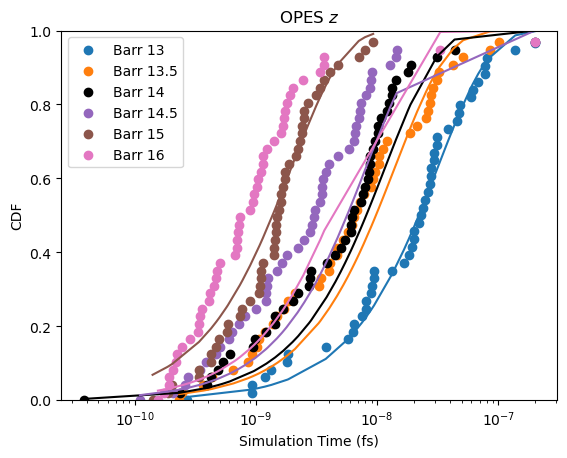

In [4]:
plt.xscale('log')
plt.ylim((0,1))

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_z[barr]),color=colors[i])

plt.title(r'OPES $z$')
plt.xlabel('Simulation Time (fs)')
plt.ylabel('CDF')
plt.legend()

In [5]:
k0s_z = {}
v_datas_z = {}
avg_ebv_z = []
avg_ebv_t_z = {}

gammas = np.linspace(0,1,21)
barrs = ['13','13.5','14','14.5','15','16']

ts_barrs = []
ix_col_barrs_z = []
ys_barrs = []
emp_rates_z = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_z[barr] = []
    
    colvars = glob(f"../../Data/cavity_orig/Z_z_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity_orig/Z_z_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-1].split('.')[-5].split('_')[-1] for colvar in colvars])
    #logs_numbers = np.array([log_file.split('/')[-2] for log_file in log_files])
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=199999, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    final_times = np.array([traj[-1][0] for traj in data])
    print(f'killed: {colvars_numbers[np.nonzero(killed)[0]]}')
    earliest_killing_time = np.inf if not np.any(killed) else np.min(final_times[killed])
    print(f'earliest killing time: {earliest_killing_time}')
    use_these = np.logical_and([traj[-1][0] < earliest_killing_time for traj in data],transitioned)
    print(f'valid: {len(np.nonzero(use_these)[0])} simulations')
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # int(np.floor(0.8*np.sum(transitioned)))
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_z[barr] = v_data

    ecdfxs[barr] = np.sort(final_times[use_these])
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:use_these.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e8)[0][0]
    emp_rates_z[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_z[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_z.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_z[barr].append(np.log(emp_rate)-np.log(avg))

46 out of 48 simulations transitioned.
killed: ['17']
earliest killing time: 9.420000447426001e-09
valid: 17 simulations
avg. max. bias: 14.644694416666667
tau_obs: 2.3310097077104462e-08, k_obs: 42899864.23875581, log k_obs: 17.574379219295473
Modified KS stat: 1.0395410876425606; p = 0.23000064108126916
ln<e^βV>: 22.62953659086497

48 out of 48 simulations transitioned.
killed: []
earliest killing time: inf
valid: 48 simulations
avg. max. bias: 15.07496175
tau_obs: 9.054439687896567e-09, k_obs: 110443057.15976441, log k_obs: 18.520010626278054
Modified KS stat: 1.3992138323467136; p = 0.03985691227793875
ln<e^βV>: 23.30686294307205

47 out of 48 simulations transitioned.
killed: []
earliest killing time: inf
valid: 47 simulations
avg. max. bias: 15.558258916666668
tau_obs: 7.547854322540244e-09, k_obs: 132487983.63975951, log k_obs: 18.70200250976676
Modified KS stat: 2.5113881189767815; p = 6.649337131681143e-06
ln<e^βV>: 23.841918173705928

47 out of 48 simulations transitioned.
ki

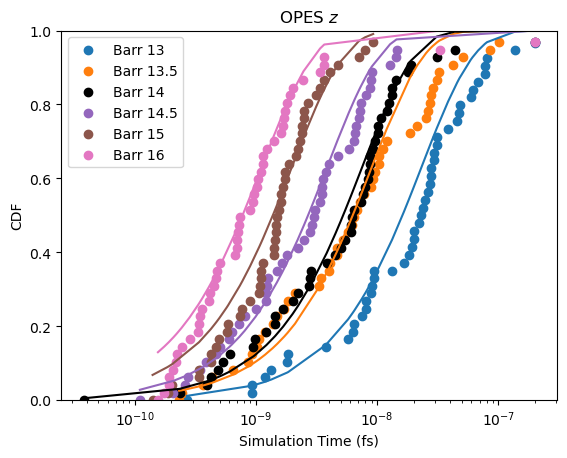

In [6]:
plt.xscale('log')
plt.ylim((0,1))

colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']

for i, barr in enumerate(barrs):
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_z[barr]),color=colors[i])

plt.title(r'OPES $z$')
plt.xlabel('Simulation Time (fs)')
plt.ylabel('CDF')
plt.legend()

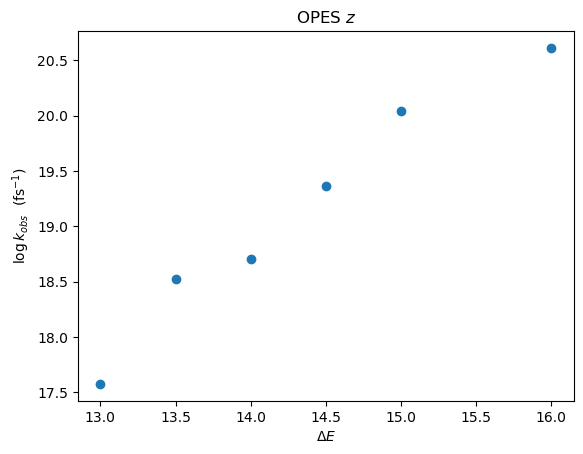

In [7]:
plt.title(r'OPES $z$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{fs}^{-1})$')
plt.xlabel(r'$\Delta E$')
plt.scatter([float(barr) for barr in barrs],[k0s_z[barr][0] for barr in barrs])

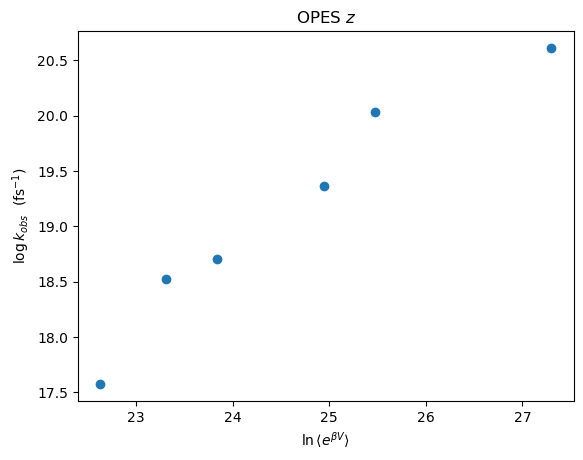

In [8]:
plt.title(r'OPES $z$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{fs}^{-1})$')
plt.scatter(avg_ebv_z,[k0s_z[barr][0] for barr in barrs])

Text(0, 0.5, '$\\ln (k/\\langle e^{\\beta\\gamma V}\\rangle)$')

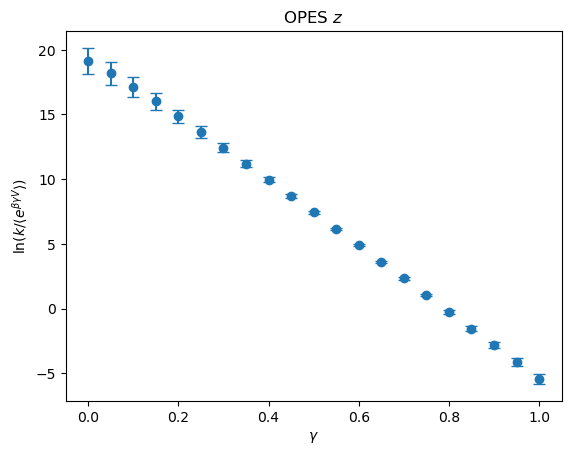

In [9]:
avgs_z = [np.mean([k0s_z[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_z = [np.var([k0s_z[barr][i] for barr in barrs]) for i in range(len(gammas))]

plt.errorbar(gammas,avgs_z,yerr=vars_z,linestyle='',marker='o',capsize=4)
#plt.axhline(np.log(true),linestyle='--',color='k',label=r'$\ln k_0$')
plt.title(r'OPES $z$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln (k/\langle e^{\beta\gamma V}\rangle)$')

Text(0, 0.5, 'Variance')

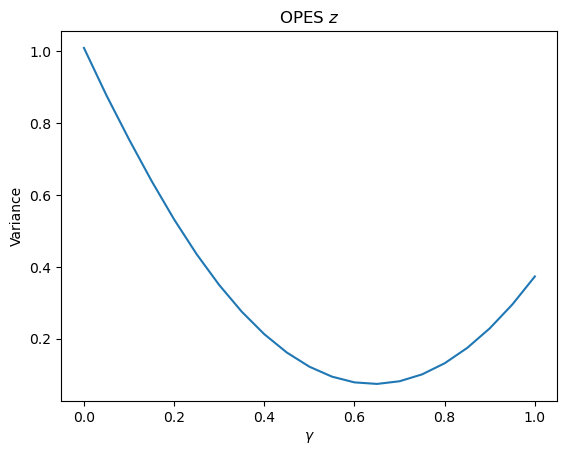

In [10]:
plt.plot(gammas,vars_z)
plt.title(r'OPES $z$')
plt.xlabel(r'$\gamma$')
plt.ylabel('Variance')

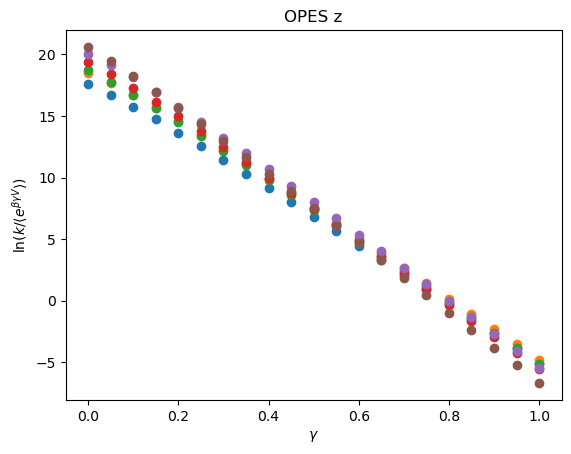

In [11]:
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln (k/\langle e^{\beta\gamma V}\rangle)$')
plt.title(r'OPES z')

for barr in barrs:
    plt.scatter(gammas,k0s_z[barr])


In [12]:
def variance(gamma):
    k0s = []
    for barr in barrs:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_z[barr]),axis=0))
        k0s.append(np.log(emp_rates_z[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_z = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_z*v_datas_z[barr]),axis=0))
    k0s.append(np.log(emp_rates_z[barr])-np.log(avg))
k0_best_z = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_z}, k0: {np.exp(k0_best_z)} s^-1, τ0: {np.exp(-k0_best_z)} s')

LEAST VAR:  gamma: 0.643290287735508, k0: 43.97840323728577 s^-1, τ0: 0.02273843355804651 s


In [13]:
k0s_rz = {}
v_datas_rz = {}
avg_ebv_rz = []
avg_ebv_t_rz = {}

gammas = np.linspace(0,1,21)
barrs = ['13','13.5','14','14.5','15','16']

ts_barrs = []
ix_col_barrs_rz = []
ys_barrs = []
emp_rates_rz = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_rz[barr] = []
    
    colvars = glob(f"../../Data/cavity_orig/Z_z_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity_orig/Z_z_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=199999, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    final_times = np.array([traj[-1][0] for traj in data])
    print(f'final_times: {np.sort(final_times)}')
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # int(np.floor(0.8*np.sum(transitioned)))
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_rz[barr] = v_data

    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_rz[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_rz[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_rz.append(np.log(avg))
    
    print('')
    

46 out of 48 simulations transitioned.
final_times: [2.68000013e-10 9.27000044e-10 9.32000044e-10 1.18400006e-09
 1.34000006e-09 1.80000009e-09 1.84400009e-09 3.76000018e-09
 5.74300027e-09 6.27500030e-09 6.46900031e-09 7.46400035e-09
 8.04000038e-09 8.07600038e-09 8.82100042e-09 8.99200043e-09
 9.39600045e-09 9.42000045e-09 1.32650006e-08 1.66060008e-08
 1.82440009e-08 1.94550009e-08 2.00200010e-08 2.00750010e-08
 2.22860011e-08 2.30290011e-08 2.38830011e-08 2.46570012e-08
 2.63090012e-08 2.72370013e-08 2.77000013e-08 2.78390013e-08
 2.93090014e-08 2.94320014e-08 3.10570015e-08 3.11020015e-08
 3.84570018e-08 4.56510022e-08 4.69520022e-08 4.78500023e-08
 5.90710028e-08 6.13340029e-08 6.80820032e-08 7.69350037e-08
 7.81440037e-08 8.05870038e-08 1.37857007e-07 2.00000009e-07]
avg. max. bias: 14.644694416666667
tau_obs: 3.180817542385066e-08, k_obs: 31438458.404947434, log k_obs: 17.26354249140161
Modified KS stat: 0.7614216643235941; p = 0.6079763299464558
ln<e^βV>: 22.62953659086497

48

In [14]:
k0s_rz = {}
v_datas_rz = {}
avg_ebv_rz = []
avg_ebv_t_rz = {}

gammas = np.linspace(0,1,21)
barrs = ['13','13.5','14','14.5','15','16']

ts_barrs = []
ix_col_barrs_rz = []
ys_barrs = []
emp_rates_rz = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_rz[barr] = []
    
    colvars = glob(f"../../Data/cavity_orig/2D_ZP_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity_orig/2D_ZP_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-1].split('.')[-5].split('_')[-1] for colvar in colvars])
    #logs_numbers = np.array([log_file.split('/')[-2] for log_file in log_files])
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=199999, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    final_times = np.array([traj[-1][0] for traj in data])
    print(f'killed: {colvars_numbers[np.nonzero(killed)[0]]}')
    earliest_killing_time = np.inf if not np.any(killed) else np.min(final_times[killed])
    print(f'earliest killing time: {earliest_killing_time}')
    use_these = np.logical_and([traj[-1][0] < earliest_killing_time for traj in data],transitioned)
    print(f'valid: {len(np.nonzero(use_these)[0])} simulations')
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # int(np.floor(0.8*np.sum(transitioned)))
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_rz[barr] = v_data

    ecdfxs[barr] = np.sort(final_times[use_these])
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:use_these.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e8)[0][0]
    emp_rates_rz[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_rz[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_rz.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_rz[barr].append(np.log(emp_rate)-np.log(avg))

46 out of 48 simulations transitioned.
killed: ['45']
earliest killing time: 1.7120000813156004e-08
valid: 18 simulations
avg. max. bias: 15.441068208333334
tau_obs: 3.2711019770671905e-08, k_obs: 30570737.537708364, log k_obs: 17.235553819768604
Modified KS stat: 1.1068451298303699; p = 0.17243973105101995
ln<e^βV>: 22.5925103593514

47 out of 48 simulations transitioned.
killed: ['17']
earliest killing time: 2.320000110194e-09
valid: 8 simulations
avg. max. bias: 15.762162083333331
tau_obs: 1.1157642413915525e-08, k_obs: 89624668.26798694, log k_obs: 18.31114115554373
Modified KS stat: 0.7109292746624175; p = 0.6929726167084977
ln<e^βV>: 23.518639830791955

48 out of 48 simulations transitioned.
killed: []
earliest killing time: inf
valid: 48 simulations
avg. max. bias: 16.212604020833336
tau_obs: 6.2722582388531915e-09, k_obs: 159432211.16208988, log k_obs: 18.88712938145936
Modified KS stat: 0.741381961496882; p = 0.6416889281100179
ln<e^βV>: 24.20716796964813

48 out of 48 simulat

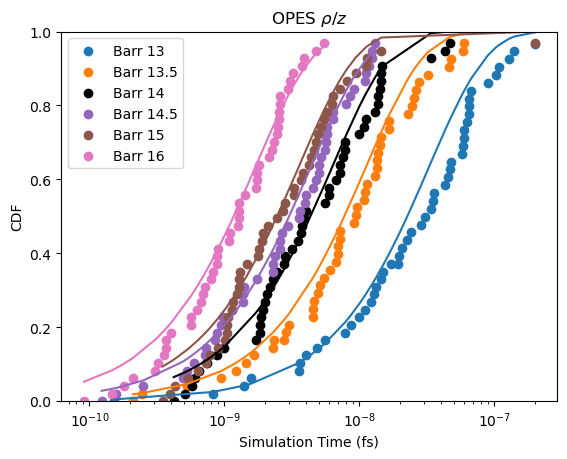

In [15]:
plt.xscale('log')
plt.ylim((0,1))
colors = ['C0','C1','k','C4','C5','C6','C7','C8','C9','C10']
#for i, barr in enumerate(barrs):
#    plt.scatter(ecdfxs[barr],ecdfys[:len(ecdfxs[barr])],label=f'Barr {barr}')
#    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_rz[barr]))
for i, barr in enumerate(barrs):
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}',color=colors[i])
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_rz[barr]),color=colors[i])


plt.title(r'OPES $\rho/z$')
plt.xlabel('Simulation Time (fs)')
plt.ylabel('CDF')
plt.legend()

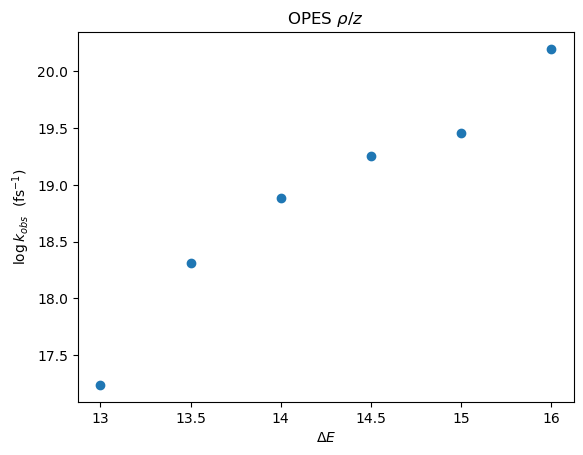

In [16]:
plt.title(r'OPES $\rho/z$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{fs}^{-1})$')
plt.xlabel(r'$\Delta E$')
plt.scatter(barrs,[k0s_rz[barr][0] for barr in barrs])

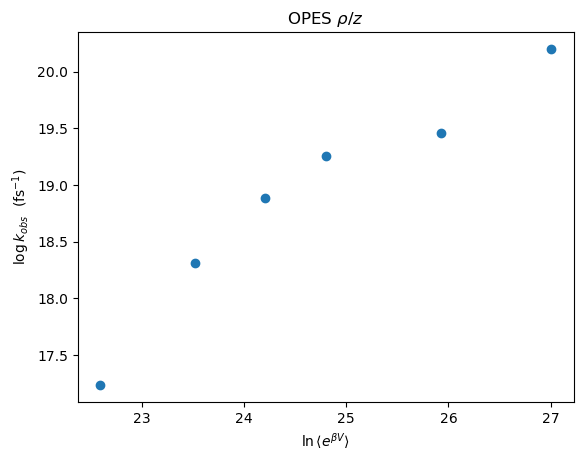

In [17]:
plt.title(r'OPES $\rho/z$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{fs}^{-1})$')
plt.scatter(avg_ebv_rz,[k0s_rz[barr][0] for barr in barrs])

Text(0, 0.5, '$\\ln (k/\\langle e^{\\beta\\gamma V}\\rangle)$')

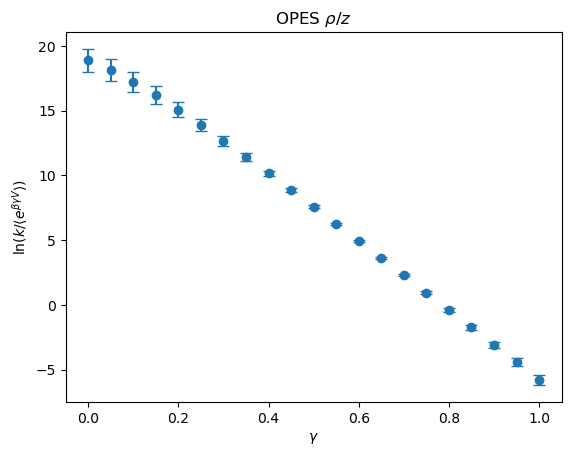

In [18]:
avgs_rz = [np.mean([k0s_rz[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_rz = [np.var([k0s_rz[barr][i] for barr in barrs]) for i in range(len(gammas))]

plt.title(r'OPES $\rho/z$')
plt.errorbar(gammas,avgs_rz,yerr=vars_rz,linestyle='',marker='o',capsize=4)
#plt.axhline(np.log(true),linestyle='--',color='k',label=r'$\ln k_0$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln (k/\langle e^{\beta\gamma V}\rangle)$')

Text(0, 0.5, 'Variance')

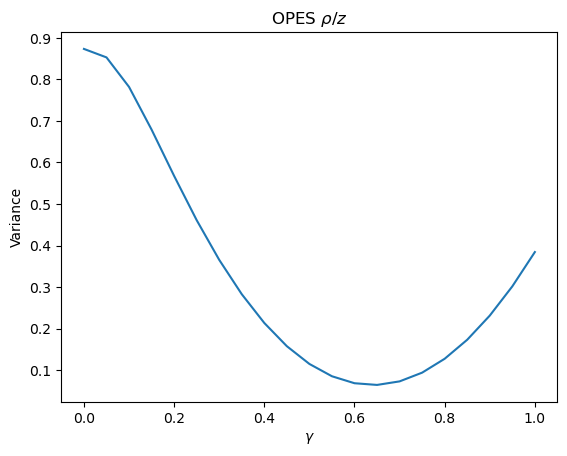

In [19]:
plt.title(r'OPES $\rho/z$')
plt.plot(gammas,vars_rz)
plt.xlabel(r'$\gamma$')
plt.ylabel('Variance')

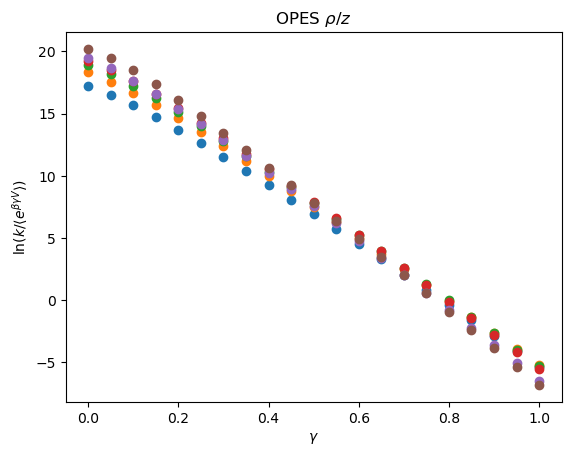

In [20]:
plt.title(r'OPES $\rho/z$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln (k/\langle e^{\beta\gamma V}\rangle)$')

for barr in barrs:
    plt.scatter(gammas,k0s_rz[barr])


In [21]:
def variance(gamma):
    k0s = []
    for barr in barrs:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_rz[barr]),axis=0))
        k0s.append(np.log(emp_rates_rz[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_rz = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_rz*v_datas_rz[barr]),axis=0))
    k0s.append(np.log(emp_rates_rz[barr])-np.log(avg))
k0_best_rz = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_rz}, k0: {np.exp(k0_best_rz)} s^-1, τ0: {np.exp(-k0_best_rz)} s')

LEAST VAR:  gamma: 0.6410960899723191, k0: 47.72703374306996 s^-1, τ0: 0.02095248586751322 s


In [22]:
k0s_r = {}
v_datas_r = {}
avg_ebv_r = []
avg_ebv_t_r = {}

gammas = np.linspace(0,1,21)
barrs = ['13.5','14','14.5','15','16']

ts_barrs = []
ix_col_barrs_r = []
ys_barrs = []
emp_rates_r = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_r[barr] = []
    
    colvars = glob(f"../../Data/cavity_orig/P_rho_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity_orig/P_rho_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    
    runs = [f"{i+1}" for i in range(num_runs)]
    if barr == "14.5":
        runs.remove("29") # barrier 14.5, run 29 was corrupted, so we exclude it.

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=199999, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    final_times = np.array([traj[-1][0] for traj in data])
    print(f'final_times: {np.sort(final_times)}')
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # int(np.floor(0.8*np.sum(transitioned)))
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_r[barr] = v_data

    emp_rate = transitioned.sum() / final_times.sum()
    emp_rates_r[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_r[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_r.append(np.log(avg))
    
    print('')
    

47 out of 48 simulations transitioned.
final_times: [6.71000032e-10 7.34000035e-10 8.27000039e-10 1.95200009e-09
 2.28900011e-09 5.57600026e-09 5.59300027e-09 5.73200027e-09
 5.85800028e-09 6.35200030e-09 6.54200031e-09 8.85200042e-09
 9.91200047e-09 1.27730006e-08 1.37580007e-08 1.64670008e-08
 2.15930010e-08 2.44820012e-08 2.45860012e-08 2.64420013e-08
 2.76700013e-08 2.99600014e-08 3.14790015e-08 3.27660016e-08
 3.31140016e-08 3.36460016e-08 3.44370016e-08 3.71790018e-08
 4.01030019e-08 4.03570019e-08 4.16310020e-08 4.18340020e-08
 4.36940021e-08 5.05800024e-08 5.76620027e-08 5.99340028e-08
 6.12770029e-08 6.92650033e-08 7.07980034e-08 7.63800036e-08
 7.97450038e-08 8.70270041e-08 9.35500044e-08 1.08608005e-07
 1.28293006e-07 1.58191008e-07 1.80275009e-07 2.00000009e-07]
avg. max. bias: 15.0805965625
tau_obs: 4.57541723859724e-08, k_obs: 21855930.243130922, log k_obs: 16.899982849689934
Modified KS stat: 0.6489421482311607; p = 0.7936492148603583
ln<e^βV>: 23.18636689745792

48 out 

There were no outliers this time, but we will still use CDF fitting for consistency.

In [23]:
k0s_r = {}
v_datas_r = {}
avg_ebv_r = []
avg_ebv_t_r = {}

gammas = np.linspace(0,1,21)
barrs = ['13.5','14','14.5','15','16']

ts_barrs = []
ix_col_barrs_r = []
ys_barrs = []
emp_rates_r = {}

num_runs = 48
ecdfxs = {}
ecdfys = {}

def poisson_CDF(t, k):
    return 1 - np.exp(-k*t)

for barr in barrs:
    k0s_r[barr] = []
    
    colvars = glob(f"../../Data/cavity_orig/P_rho_cavity_opes/barrier{barr}/*.opes.out")
    log_files = glob(f"../../Data/cavity_orig/P_rho_cavity_opes/barrier{barr}/*.log")
    data = RM.get_data(colvars,0,1,time_scale_factor=1e-15)
    num_runs = len(data)
    colvars_numbers = np.array([colvar.split('/')[-1].split('.')[-5].split('_')[-1] for colvar in colvars])
    #logs_numbers = np.array([log_file.split('/')[-2] for log_file in log_files])
    
    runs = [f"{i+1}" for i in range(num_runs)]

    # Handle transitions and killed simulations
    transitioned = RM.get_event(data, log_files=log_files, quiet=False)
    event_notend = RM.get_event(data, maxlen=199999, quiet=True)
    killed = np.logical_xor(transitioned, event_notend)
    final_times = np.array([traj[-1][0] for traj in data])
    print(f'killed: {colvars_numbers[np.nonzero(killed)[0]]}')
    earliest_killing_time = np.inf if not np.any(killed) else np.min(final_times[killed])
    print(f'earliest killing time: {earliest_killing_time}')
    use_these = np.logical_and([traj[-1][0] < earliest_killing_time for traj in data],transitioned)
    print(f'valid: {len(np.nonzero(use_these)[0])} simulations')
    
    max_biases = []
    for traj in data:
        max_biases.append(np.max(traj[:,1]+np.float64(barr)))
    print(f'avg. max. bias: {np.mean(max_biases)}')

    colvar_maxrow_count = max(len(traj[:,0]) for traj in data)
    colvar_row_counts = np.sort([len(traj[:,0]) for traj in data])
    max_index = colvar_row_counts[-1] # int(np.floor(0.8*np.sum(transitioned)))
    min_index = 0 # colvar_row_counts[0] # 0
    v_data = np.full((len(data), max_index-min_index), np.nan)
    for i, traj in enumerate(data):
        v_data[i,:(min(len(traj),max_index)-min_index)] = traj[min_index:max_index,1]+np.float64(barr)
    v_datas_r[barr] = v_data

    ecdfxs[barr] = np.sort(final_times[use_these])
    ecdfys[barr] = np.linspace(1/num_runs,1,num_runs)[:use_these.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs[barr],ecdfys[barr],p0=1e8)[0][0]
    emp_rates_r[barr] = emp_rate
    print(f'tau_obs: {1/emp_rate}, k_obs: {emp_rate}, log k_obs: {np.log(emp_rate)}')
    
    ks_stat, p, t, cum_hazard = ksc.ks_1samp_censored(final_times,transitioned,lambda t: 1-poisson_CDF(t,emp_rate),return_beta=True)
    print(f'Modified KS stat: {ks_stat}; p = {p}')
    ecdfxs[barr] = t
    ecdfys[barr] = 1-np.exp(-np.array(cum_hazard[:-1]))
    
    #avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=1)) # Average over time, then over simulations
    avg = np.mean(np.nanmean(np.exp(beta*v_data),axis=0)) # Average over simulations, then over time
    avg_ebv_t_r[barr] = np.nanmean(np.exp(beta*v_data),axis=0)
    print(f'ln<e^βV>: {np.log(avg)}')
    avg_ebv_r.append(np.log(avg))
    
    print('')
    
    for gamma in gammas:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_data),axis=0))
        k0s_r[barr].append(np.log(emp_rate)-np.log(avg))

47 out of 48 simulations transitioned.
killed: []
earliest killing time: inf
valid: 47 simulations
avg. max. bias: 15.0805965625
tau_obs: 4.262709786751408e-08, k_obs: 23459255.96689742, log k_obs: 16.970775685720664
Modified KS stat: 0.5997384282363551; p = 0.8646286415080047
ln<e^βV>: 23.18636689745792

48 out of 48 simulations transitioned.
killed: []
earliest killing time: inf
valid: 48 simulations
avg. max. bias: 15.511893291666667
tau_obs: 1.2488007473830085e-08, k_obs: 80076825.8743922, log k_obs: 18.19849705525251
Modified KS stat: 0.7661710116695637; p = 0.6000243210269549
ln<e^βV>: 24.043459507118776

47 out of 47 simulations transitioned.
killed: []
earliest killing time: inf
valid: 47 simulations
avg. max. bias: 16.025400617021276
tau_obs: 7.82225913337808e-09, k_obs: 127840305.84373459, log k_obs: 18.666292432374046
Modified KS stat: 0.9937237813007912; p = 0.2767883396449121
ln<e^βV>: 24.809215379905446

48 out of 48 simulations transitioned.
killed: []
earliest killing t

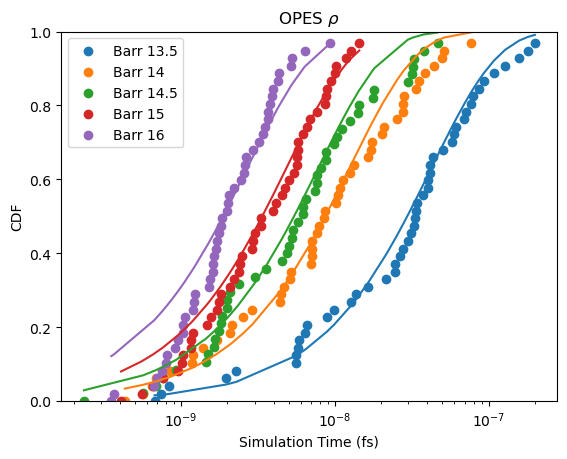

In [24]:
plt.xscale('log')
plt.ylim((0,1))
for i, barr in enumerate(barrs):
    plt.scatter(ecdfxs[barr],ecdfys[barr],label=f'Barr {barr}')
    plt.plot(ecdfxs[barr],poisson_CDF(ecdfxs[barr],emp_rates_r[barr]))

plt.title(r'OPES $\rho$')
plt.xlabel('Simulation Time (fs)')
plt.ylabel('CDF')
plt.legend()

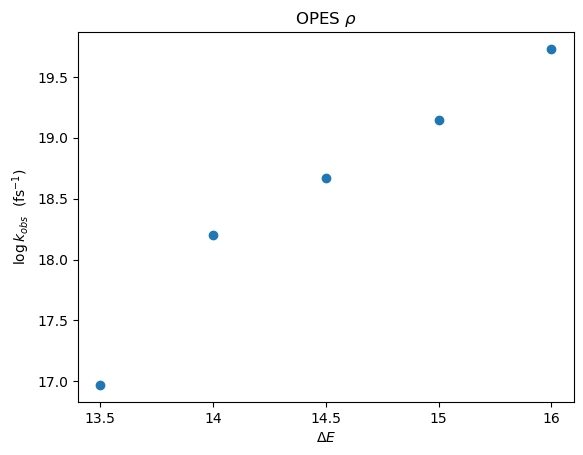

In [25]:
plt.title(r'OPES $\rho$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{fs}^{-1})$')
plt.xlabel(r'$\Delta E$')
plt.scatter(barrs,[k0s_r[barr][0] for barr in barrs])

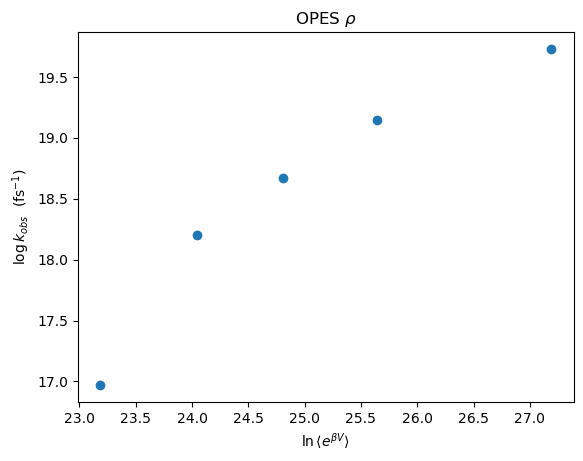

In [26]:
plt.title(r'OPES $\rho$')
plt.xlabel(r'$\ln \langle e^{\beta V} \rangle$')
plt.ylabel(r'$\log k_{obs}~~(\mathrm{fs}^{-1})$')
plt.scatter(avg_ebv_r,[k0s_r[barr][0] for barr in barrs])

Text(0, 0.5, '$\\ln (k/\\langle e^{\\beta\\gamma V}\\rangle)$')

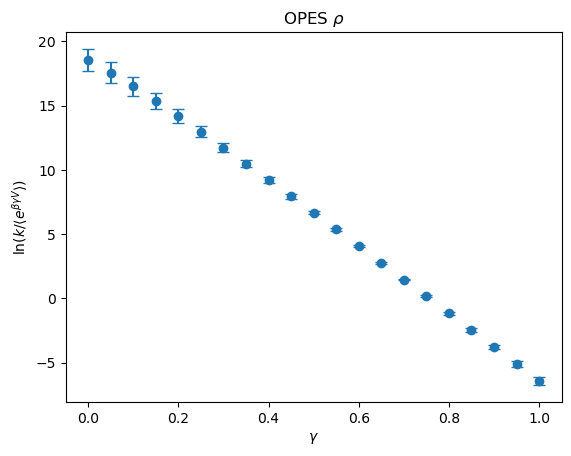

In [27]:
avgs_r = [np.mean([k0s_r[barr][i] for barr in barrs]) for i in range(len(gammas))]
vars_r = [np.var([k0s_r[barr][i] for barr in barrs]) for i in range(len(gammas))]

plt.title(r'OPES $\rho$')
plt.errorbar(gammas,avgs_r,yerr=vars_r,linestyle='',marker='o',capsize=4)
#plt.axhline(np.log(true),linestyle='--',color='k',label=r'$\ln k_0$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln (k/\langle e^{\beta\gamma V}\rangle)$')

Text(0, 0.5, 'Variance')

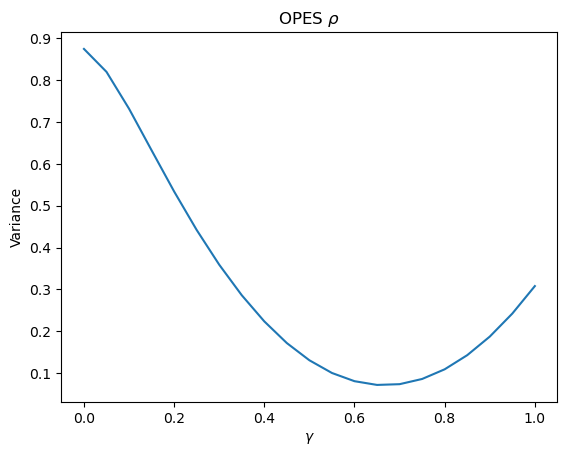

In [28]:
plt.title(r'OPES $\rho$')
plt.plot(gammas,vars_r)
plt.xlabel(r'$\gamma$')
plt.ylabel('Variance')

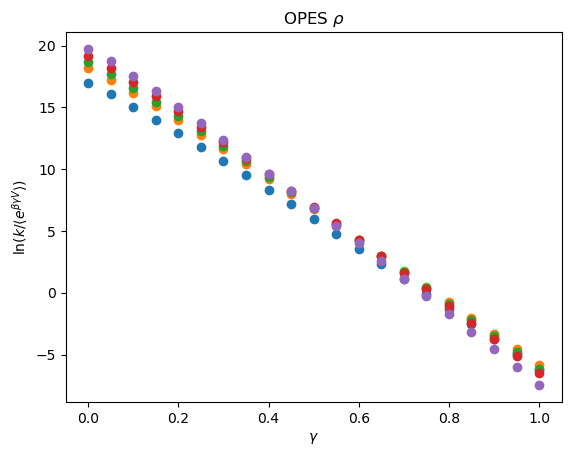

In [29]:
plt.title(r'OPES $\rho$')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$\ln (k/\langle e^{\beta\gamma V}\rangle)$')

for barr in barrs:
    plt.scatter(gammas,k0s_r[barr])


In [30]:
def variance(gamma):
    k0s = []
    for barr in barrs:
        avg = np.mean(np.nanmean(np.exp(beta*gamma*v_datas_r[barr]),axis=0))
        k0s.append(np.log(emp_rates_r[barr])-np.log(avg))
    return np.var(k0s)

gamma_best_r = optimize.minimize_scalar(variance,bounds=(0.,1.)).x
k0s = []
for barr in barrs:
    avg = np.mean(np.nanmean(np.exp(beta*gamma_best_r*v_datas_r[barr]),axis=0))
    k0s.append(np.log(emp_rates_r[barr])-np.log(avg))
k0_best_r = np.mean(k0s)
print(f'LEAST VAR:  gamma: {gamma_best_r}, k0: {np.exp(k0_best_r)} s^-1, τ0: {np.exp(-k0_best_r)} s')

LEAST VAR:  gamma: 0.6666768407488807, k0: 10.328914128862841 s^-1, τ0: 0.09681559818622432 s


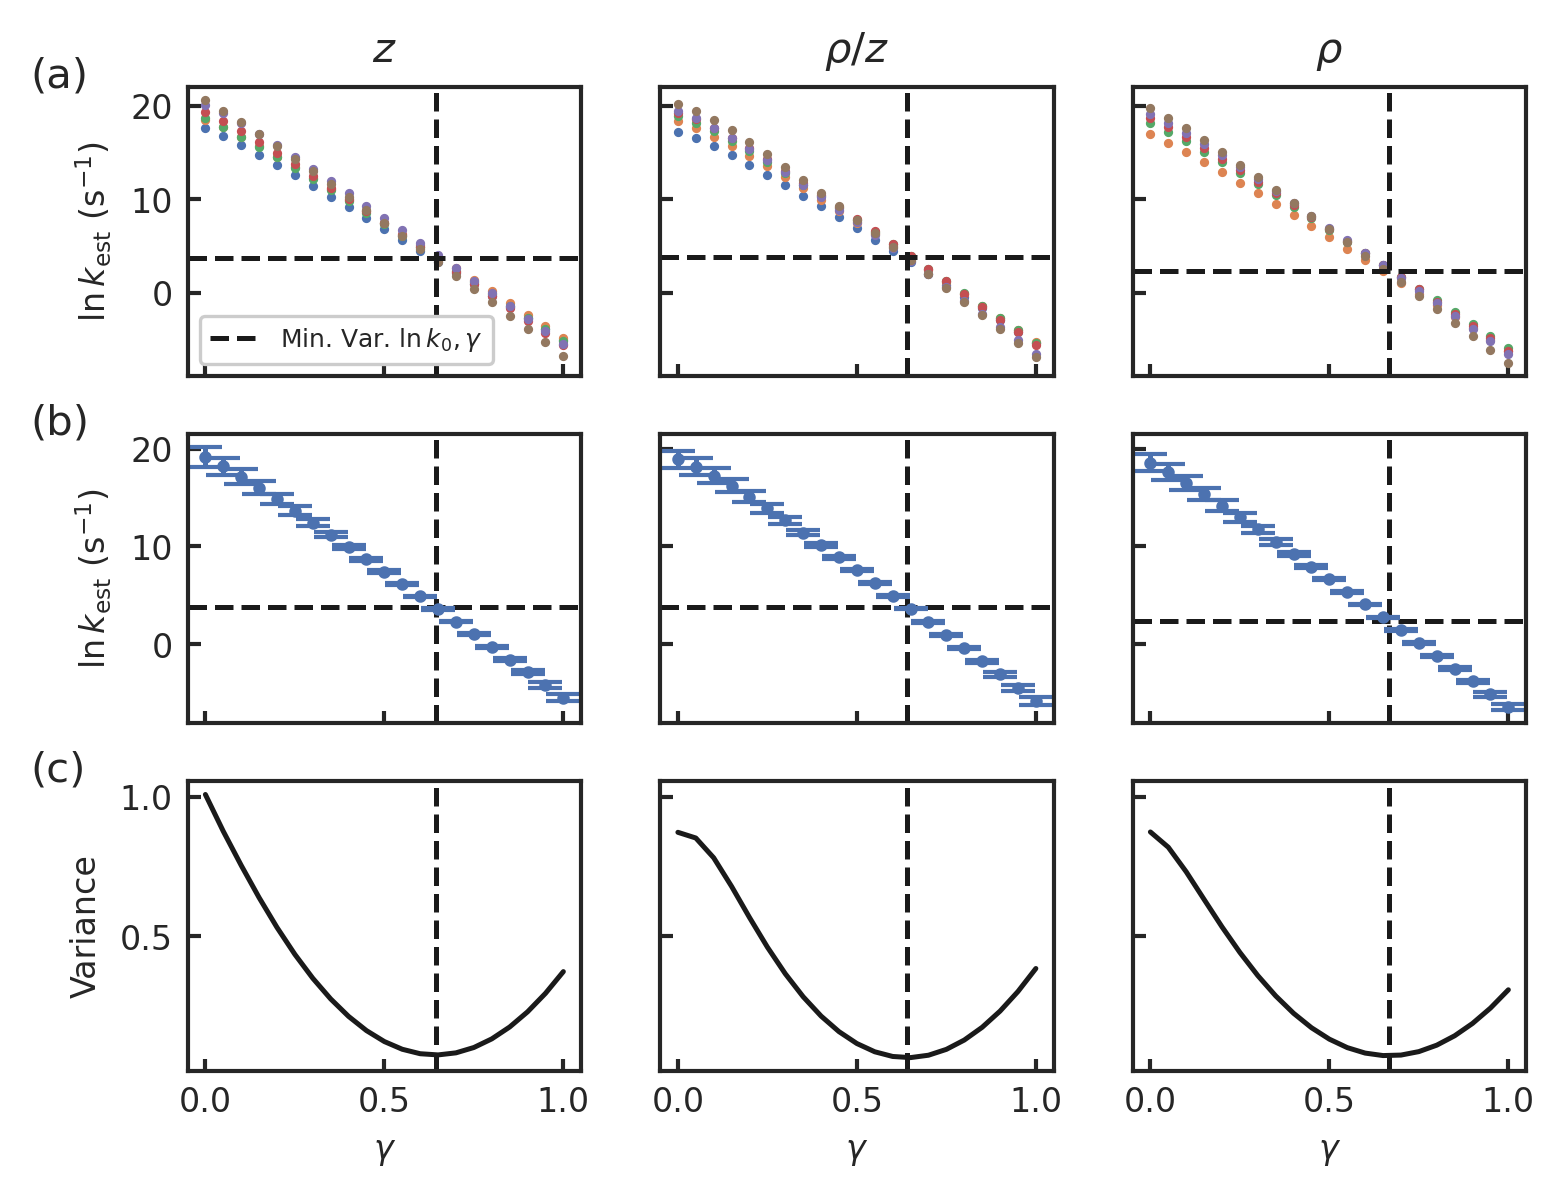

In [32]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

barrs_z = ['13','13.5','14','14.5','15','16']
barrs_rz = ['13','13.5','14','14.5','15','16']
barrs_r = ['13.5','14','14.5','15','16']

fig, axs = plt.subplots(3,3,figsize=(21/4,4),dpi=300,sharey='row',sharex=True)
fig.subplots_adjust(wspace=0.2,bottom=0.1,left=0.12,right=0.97,top=0.92)

axs[0,0].axvline(gamma_best_z,linestyle='--',color='k',label=r'Min. Var. $\ln k_0,\gamma$')
axs[1,0].axvline(gamma_best_z,linestyle='--',color='k')
axs[2,0].axvline(gamma_best_z,linestyle='--',color='k')
axs[0,0].axhline(k0_best_z,linestyle='--',color='k')
axs[1,0].axhline(k0_best_z,linestyle='--',color='k')
axs[0,0].legend(framealpha=1)

axs[0,1].axvline(gamma_best_rz,linestyle='--',color='k')
axs[1,1].axvline(gamma_best_rz,linestyle='--',color='k')
axs[2,1].axvline(gamma_best_rz,linestyle='--',color='k')
axs[0,1].axhline(k0_best_rz,linestyle='--',color='k')
axs[1,1].axhline(k0_best_rz,linestyle='--',color='k')

axs[0,2].axvline(gamma_best_r,linestyle='--',color='k')
axs[1,2].axvline(gamma_best_r,linestyle='--',color='k')
axs[2,2].axvline(gamma_best_r,linestyle='--',color='k')
axs[0,2].axhline(k0_best_r,linestyle='--',color='k')
axs[1,2].axhline(k0_best_r,linestyle='--',color='k')

#axs[0,0].set_ylim((-18,-8))
#axs[0,0].set_yticks([-9,-12,-15,-18])
#axs[1,0].set_ylim((-18,-8))
#axs[1,0].set_yticks([-9,-12,-15,-18])

for i, barr in enumerate(barrs_z):
    axs[0,0].scatter(gammas,k0s_z[barr],label=f'Barr {barr}',color=f'C{i}',s=2)

for i, barr in enumerate(barrs_rz):
    axs[0,1].scatter(gammas,k0s_rz[barr],label=f'Barr {barr}',color=f'C{i}',s=2)

for i, barr in enumerate(barrs_r):
    axs[0,2].scatter(gammas,k0s_r[barr],label=f'Barr {barr}',color=f'C{i+1}',s=2)

axs[1,0].errorbar(gammas,avgs_z,yerr=vars_z,linestyle='',marker='o',capsize=4,markersize=2)
axs[1,1].errorbar(gammas,avgs_rz,yerr=vars_rz,linestyle='',marker='o',capsize=4,markersize=2)
axs[1,2].errorbar(gammas,avgs_r,yerr=vars_r,linestyle='',marker='o',capsize=4,markersize=2)
axs[2,0].plot(gammas,vars_z,color='k')
axs[2,1].plot(gammas,vars_rz,color='k')
axs[2,2].plot(gammas,vars_r,color='k')

axs[0,0].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{s}^{-1})$')
axs[1,0].set_ylabel(r'$\ln k_\mathrm{est}~(\mathrm{s}^{-1})$')
axs[2,0].set_ylabel('Variance')
axs[2,0].set_xlabel(r'$\gamma$')
axs[2,1].set_xlabel(r'$\gamma$')
axs[2,2].set_xlabel(r'$\gamma$')

axs[0,0].set_title(r'$z$')
axs[0,1].set_title(r'$\rho/z$')
axs[0,2].set_title(r'$\rho$')

#right_shift = 0.1
axs[0,0].text(-0.4,1.0,"(a)",fontsize=10,transform=axs[0,0].transAxes)
#axs[0,0].annotate("",xy=(0.05+right_shift,-14),xytext=(0.05+right_shift,-23),arrowprops={'arrowstyle':'->','color':'k'})
#axs[0,0].text(0.12+right_shift,0.85,r"$\Delta E$",fontsize=8,transform=axs[0,0].transAxes)
#axs[0,0].text(0.21+right_shift,0.85,r"$\uparrow$",fontsize=8,transform=axs[0,0].transAxes)
#axs[0,1].annotate("",xy=(0.05+right_shift,-14),xytext=(0.05+right_shift,-23),arrowprops={'arrowstyle':'->','color':'k'})
#axs[0,1].text(0.12+right_shift,0.85,r"$\Delta E$",fontsize=8,transform=axs[0,1].transAxes)
#axs[0,1].text(0.21+right_shift,0.85,r"$\uparrow$",fontsize=8,transform=axs[0,1].transAxes)
axs[1,0].text(-0.4,1.0,"(b)",fontsize=10,transform=axs[1,0].transAxes)
axs[2,0].text(-0.4,1.0,"(c)",fontsize=10,transform=axs[2,0].transAxes)

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

plt.savefig("EATRf_FigS7.pdf",format='pdf')